# Thesis Experiment: SAC-Based Gamma Controller (Weekly Rebalancing)
**Setup:** 7-Day Rebalancing Frequency | SAC replaces PPO | Multi-seed evaluation

**Perubahan utama dari versi PPO:**
- `PPO` → `SAC` (Soft Actor-Critic) — off-policy, lebih efisien dengan data terbatas
- Tambah `EquallyWeighted` & `ClassicalMarkowitz` sebagai benchmark
- Multi-seed training (3 seeds) untuk credibility statistik
- Reward normalization untuk stabilitas training
- Tambah `Calmar Ratio` pada metrik evaluasi

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
import warnings
import os
import gymnasium as gym
from gymnasium import spaces

# === PERUBAHAN UTAMA: Import SAC, bukan PPO ===
from stable_baselines3 import SAC, PPO          # PPO tetap untuk perbandingan
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnNoModelImprovement

from scipy.optimize import minimize

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

SEEDS = [42]   # Multi-seed untuk reproducibility
print('Libraries loaded. SAC mode active.')
print(f'Training seeds: {SEEDS}')

Libraries loaded. SAC mode active.
Training seeds: [42]


## Phase 1: Data Preparation

In [2]:
file_old  = 'crypto_data_real.xlsx'
file_2024 = 'crypto_data_2024.xlsx'

def load_and_preprocess(f1, f2):
    r_old  = pd.read_excel(f1, sheet_name='Returns', index_col=0)
    r_2024 = pd.read_excel(f2, sheet_name='Returns', index_col=0)
    r_old.index  = pd.to_datetime(r_old.index)
    r_2024.index = pd.to_datetime(r_2024.index)
    assets = list(set(r_old.columns) & set(r_2024.columns))
    if 'USDT' in assets:
        assets.remove('USDT')
        print('USDT removed from assets.')
    assets.sort()
    return r_old[assets], r_2024[assets], assets

ret_old, ret_2024, assets = load_and_preprocess(file_old, file_2024)

SET_WINDOW    = 30
SET_REBALANCE = 7
print(f'Data loaded. Assets ({len(assets)}): {assets}')
print(f'Training period : {ret_old.index[0].date()} – {ret_old.index[-1].date()} ({len(ret_old)} days)')
print(f'Test period     : {ret_2024.index[0].date()} – {ret_2024.index[-1].date()} ({len(ret_2024)} days)')

USDT removed from assets.
Data loaded. Assets (9): ['BCH', 'BNB', 'BTC', 'EOS', 'ETH', 'LTC', 'TRX', 'XLM', 'XRP']
Training period : 2017-09-15 – 2019-10-17 (763 days)
Test period     : 2024-01-02 – 2024-12-31 (365 days)


## Phase 2: Core Functions

In [3]:
def apply_rmt_filter(returns_window):
    T, N = returns_window.shape
    corr_mat = returns_window.corr().fillna(0).values
    eigenvalues, eigenvectors = np.linalg.eigh(corr_mat)
    Q = T / N
    lambda_max = (1 + np.sqrt(1/Q))**2
    eigenvalues[eigenvalues < lambda_max] = 0
    corr_denoised = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
    np.fill_diagonal(corr_denoised, 1)
    return corr_denoised


def get_centrality_weights(returns_window, gamma=1.0):
    T, N = returns_window.shape
    mu    = returns_window.mean().values
    sigma = returns_window.std().values
    corr_f = apply_rmt_filter(returns_window)
    cov_f  = np.outer(sigma, sigma) * corr_f + np.eye(N) * 1e-8
    dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
    G_full = nx.from_numpy_array(dist_mat)
    mst = nx.minimum_spanning_tree(G_full)
    try:
        centrality = nx.eigenvector_centrality(mst, max_iter=2000)
        cent_vec = np.array([centrality[i] for i in range(N)])
    except:
        cent_vec = np.array(list(nx.degree_centrality(mst).values()))
    fun  = lambda w: w.T @ cov_f @ w + gamma * np.sum(cent_vec * w)
    cons = (
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)},
    )
    bnds = tuple((0, 0.4) for _ in range(N))
    res  = minimize(fun, np.ones(N)/N, method='SLSQP', bounds=bnds, constraints=cons)
    return res.x if res.success else np.ones(N)/N


def get_network_metrics(returns_window):
    T, N = returns_window.shape
    corr_f  = apply_rmt_filter(returns_window)
    density = np.sum(np.abs(corr_f) > 0.1) / (N * N)
    dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
    G_full = nx.from_numpy_array(dist_mat)
    mst = nx.minimum_spanning_tree(G_full)
    mst_dist = sum(d['weight'] for _, _, d in mst.edges(data=True))
    try:
        centrality = nx.eigenvector_centrality(mst, max_iter=2000)
        cent_vec = np.array([centrality[i] for i in range(N)])
    except:
        cent_vec = np.array(list(nx.degree_centrality(mst).values()))
    return np.array([
        np.std(cent_vec)  * 10,
        np.mean(cent_vec) * 10,
        mst_dist          * 0.1,
        np.max(cent_vec),
        density
    ], dtype=np.float32)


def calculate_metrics(returns_series):
    """Metrik performa portfolio — termasuk Calmar Ratio."""
    total_ret = (1 + returns_series).prod() - 1
    ann_ret   = (1 + total_ret) ** (252 / len(returns_series)) - 1
    ann_vol   = returns_series.std() * np.sqrt(252)
    sharpe    = ann_ret / ann_vol if ann_vol > 0 else 0
    cumulative = (1 + returns_series).cumprod()
    peak       = cumulative.cummax()
    drawdown   = (cumulative - peak) / peak
    max_dd     = drawdown.min()
    # Calmar = Ann.Return / |Max Drawdown|
    calmar = ann_ret / abs(max_dd) if max_dd != 0 else 0
    return {
        'Total Return'   : total_ret,
        'Ann. Return'    : ann_ret,
        'Ann. Volatility': ann_vol,
        'Sharpe Ratio'   : sharpe,
        'Calmar Ratio'   : calmar,
        'Max Drawdown'   : max_dd,
    }

print('Core functions defined.')

Core functions defined.


In [4]:
class PortfolioStrategy:
    def __init__(self, name):
        self.name = name
        self.last_gamma = 1.0
    def compute_weights(self, returns_window): raise NotImplementedError()


class EquallyWeighted(PortfolioStrategy):
    """Benchmark 1: 1/N Equal Weight."""
    def compute_weights(self, rw):
        return np.ones(rw.shape[1]) / rw.shape[1]


class ClassicalMarkowitz(PortfolioStrategy):
    """Benchmark 2: Minimum Variance (no network regularization)."""
    def compute_weights(self, rw):
        cov = rw.cov().values
        inv_cov = np.linalg.pinv(cov)
        w = np.clip(inv_cov @ np.ones(cov.shape[0]), 0, 1)
        return w / np.sum(w)


class NetworkMarkowitz(PortfolioStrategy):
    """NW baseline: fixed gamma."""
    def __init__(self, name, gamma=1.0):
        super().__init__(name)
        self.gamma = gamma
    def compute_weights(self, rw):
        return get_centrality_weights(rw, self.gamma)


# === PERUBAHAN: RLNetworkMarkowitz sekarang support SAC dan PPO ===
class RLNetworkMarkowitz(PortfolioStrategy):
    """
    RL-based gamma controller.
    algo: 'sac' atau 'ppo' — menentukan loader yang digunakan.
    """
    def __init__(self, name, model_path, algo='sac',
                 gamma_center=1.0, gamma_range=1.0):
        super().__init__(name)
        if algo == 'sac':
            self.model = SAC.load(model_path)
        else:
            self.model = PPO.load(model_path)
        self.gamma_center = gamma_center
        self.gamma_range  = gamma_range

    def compute_weights(self, rw):
        nw_feat = get_network_metrics(rw)
        short_ret  = rw.iloc[-5:].mean().mean()
        long_ret   = rw.mean().mean()
        momentum   = short_ret - long_ret
        recent_vol = rw.iloc[-5:].std().mean()
        mkt_feat = np.array(
            [short_ret*100, momentum*100, recent_vol*100, 0.0],
            dtype=np.float32
        )
        obs = np.nan_to_num(np.concatenate([nw_feat, mkt_feat]))
        action, _ = self.model.predict(obs, deterministic=True)
        self.last_gamma = self.gamma_center + float(action[0]) * self.gamma_range
        return get_centrality_weights(rw, gamma=self.last_gamma)

print('Strategy classes defined (EquallyWeighted, ClassicalMarkowitz, NetworkMarkowitz, RLNetworkMarkowitz).')

Strategy classes defined (EquallyWeighted, ClassicalMarkowitz, NetworkMarkowitz, RLNetworkMarkowitz).


## Phase 3: Environment & Precompute

**Perubahan vs versi PPO:**
- `action_space`: tetap `[-1, 1]` — SAC secara internal menggunakan `tanh` squashing, jadi batas ini konsisten
- Tambah `reward_normalization`: running mean/std agar scale reward stabil selama training SAC
- Mode reward baru: `'sharpe_incremental'` — lebih informatif dari `excess_nw`

In [5]:
def precompute_env_data(returns_data, window_size=30):
    n_steps = len(returns_data) - window_size
    obs_cache, opt_cache, baseline_ret_cache = {}, {}, {}
    print(f'Precomputing {n_steps} window positions...')
    for i in range(window_size, len(returns_data)):
        win = returns_data.iloc[i - window_size : i]
        T, N = win.shape
        nw_feat   = get_network_metrics(win)
        short_ret = win.iloc[-5:].mean().mean()
        long_ret  = win.mean().mean()
        mkt_feat  = np.array(
            [short_ret*100, (short_ret-long_ret)*100, win.iloc[-5:].std().mean()*100, 0.0],
            dtype=np.float32
        )
        obs_cache[i] = (nw_feat, mkt_feat)
        mu    = win.mean().values
        sigma = win.std().values
        corr_f = apply_rmt_filter(win)
        cov_f  = np.outer(sigma, sigma) * corr_f + np.eye(N) * 1e-8
        dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
        mst = nx.minimum_spanning_tree(nx.from_numpy_array(dist_mat))
        try:
            cent = nx.eigenvector_centrality(mst, max_iter=2000)
            cent_vec = np.array([cent[j] for j in range(N)])
        except:
            cent_vec = np.array(list(nx.degree_centrality(mst).values()))
        opt_cache[i] = (cov_f, cent_vec, mu)
        w_base = fast_centrality_weights(cov_f, cent_vec, mu, gamma=1.0)
        baseline_ret_cache[i] = np.dot(w_base, returns_data.iloc[i].values)
    print(f'Precomputation done! ({n_steps} positions cached)')
    return obs_cache, opt_cache, baseline_ret_cache


def fast_centrality_weights(cov_f, cent_vec, mu, gamma):
    N   = len(mu)
    fun = lambda w: w.T @ cov_f @ w + gamma * np.sum(cent_vec * w)
    cons = (
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)},
    )
    res = minimize(fun, np.ones(N)/N, method='SLSQP',
                   bounds=tuple((0, 0.4) for _ in range(N)), constraints=cons)
    return res.x if res.success else np.ones(N)/N

print('Precompute functions defined.')

Precompute functions defined.


In [6]:
class GammaPortfolioEnvFast(gym.Env):
    """
    Environment dengan gamma centering + reward normalization.

    Perbedaan dari versi PPO:
    - Reward normalization (running stats) → lebih stabil untuk SAC
    - Mode 'sharpe_incremental': reward = rolling_sharpe - benchmark_sharpe
    - action_space tetap [-1, 1]; SAC menggunakan tanh squashing secara internal
    """
    def __init__(self, returns_data, obs_cache, opt_cache,
                 baseline_ret_cache=None, window_size=30,
                 reward_mode='excess_nw',
                 gamma_center=1.0, gamma_range=1.0,
                 normalize_reward=True):
        super().__init__()
        self.data               = returns_data
        self.obs_cache          = obs_cache
        self.opt_cache          = opt_cache
        self.baseline_ret_cache = baseline_ret_cache or {}
        self.window_size        = window_size
        self.reward_mode        = reward_mode
        self.gamma_center       = gamma_center
        self.gamma_range        = gamma_range
        self.normalize_reward   = normalize_reward
        self.current_step       = window_size
        self.port_val           = 1.0
        self.peak_val           = 1.0
        # Running reward stats untuk normalisasi
        self._rew_mean = 0.0
        self._rew_var  = 1.0
        self._rew_count = 0
        # Recent returns buffer untuk sharpe_incremental
        self._ret_buffer = []
        # Action & observation space — sama dengan versi PPO
        self.action_space      = spaces.Box(low=-1.0, high=1.0, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(9,), dtype=np.float32)

    def _action_to_gamma(self, action):
        return self.gamma_center + float(action) * self.gamma_range

    def _get_obs(self):
        nw_feat, mkt_feat = self.obs_cache[self.current_step]
        mf = mkt_feat.copy()
        mf[3] = self.port_val - 1
        return np.concatenate([nw_feat, mf])

    def _normalize_reward(self, r):
        """Welford online normalization."""
        if not self.normalize_reward:
            return r
        self._rew_count += 1
        delta = r - self._rew_mean
        self._rew_mean += delta / self._rew_count
        self._rew_var  += delta * (r - self._rew_mean)
        std = max(np.sqrt(self._rew_var / self._rew_count), 1e-6)
        return np.clip(r / std, -10.0, 10.0)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = self.window_size
        self.port_val     = 1.0
        self.peak_val     = 1.0
        self._ret_buffer  = []
        return self._get_obs(), {}

    def step(self, action):
        gamma    = self._action_to_gamma(action[0])
        cov_f, cent_vec, mu = self.opt_cache[self.current_step]
        w        = fast_centrality_weights(cov_f, cent_vec, mu, gamma)
        port_ret = np.dot(w, self.data.iloc[self.current_step].values)

        self.port_val *= (1 + port_ret)
        self.peak_val  = max(self.peak_val, self.port_val)
        drawdown = (self.port_val - self.peak_val) / self.peak_val
        nw_ret   = self.baseline_ret_cache.get(self.current_step,
                        self.data.iloc[self.current_step].mean())
        self._ret_buffer.append(port_ret)
        if len(self._ret_buffer) > 20:
            self._ret_buffer.pop(0)

        # ── Reward computation ────────────────────────────────────────────
        if self.reward_mode == 'excess_nw':
            raw = (port_ret - nw_ret) * 100

        elif self.reward_mode == 'sharpe_incremental':
            # Rolling 20-day Sharpe selisih vs NW baseline
            if len(self._ret_buffer) >= 5:
                buf = np.array(self._ret_buffer)
                port_sharpe = buf.mean() / (buf.std() + 1e-8)
            else:
                port_sharpe = 0.0
            raw = port_sharpe * 10   # scale

        elif self.reward_mode == 'risk_adjusted_excess':
            excess     = (port_ret - nw_ret) * 100
            dd_penalty = min(abs(drawdown) * 10, 2.0)
            raw = excess - dd_penalty

        elif self.reward_mode == 'defensive':
            raw = (port_ret - 2.0 * abs(drawdown)) * 100

        elif self.reward_mode == 'total_return':
            raw = port_ret * 100

        else:  # sharpe-like default
            std = self.data.iloc[
                self.current_step - self.window_size : self.current_step
            ].values.std()
            raw = port_ret / (std + 1e-6) * 10

        reward = self._normalize_reward(raw)
        self.current_step += 1
        done = self.current_step >= len(self.data) - 1
        return self._get_obs(), reward, done, False, {}


print('GammaPortfolioEnvFast defined (with reward normalization).')

GammaPortfolioEnvFast defined (with reward normalization).


## Phase 4: Backtest Engine (Fixed Frequency Rebalancing)

In [7]:
def run_backtest_with_frequency(strategy, data, window=30, rebalance_freq=7):
    rets, dates, weights_history, gamma_history = [], [], [], []
    current_weights = None
    current_gamma   = 1.0
    print(f'Processing {strategy.name} (Freq: {rebalance_freq} days)...')
    for i in range(window, len(data)):
        if (i - window) % rebalance_freq == 0:
            window_df       = data.iloc[i-window:i]
            current_weights = strategy.compute_weights(window_df)
            current_gamma   = getattr(strategy, 'last_gamma', 1.0)
        if current_weights is not None:
            daily_ret = np.dot(current_weights, data.iloc[i].values)
            rets.append(daily_ret)
            dates.append(data.index[i])
            weights_history.append(current_weights)
            gamma_history.append(current_gamma)
    ret_series  = pd.Series(rets, index=dates, name=strategy.name)
    wts_df      = pd.DataFrame(weights_history, index=dates, columns=data.columns)
    gamma_series = pd.Series(gamma_history, index=dates, name=strategy.name)
    return ret_series, wts_df, gamma_series

print('Backtest engine defined.')

Backtest engine defined.


## Phase 5: SAC Training (Multi-Seed)

**Perubahan utama vs PPO:**

| Parameter | PPO (lama) | SAC (baru) | Alasan |
|-----------|-----------|-----------|--------|
| Algorithm | On-policy | Off-policy | SAC reuse data lewat replay buffer |
| `n_steps` | 2048 (rollout buffer) | — (tidak ada) | SAC update setiap step |
| `buffer_size` | — | 50000 | SAC menyimpan semua pengalaman |
| `ent_coef` | 0.01 (manual) | `'auto'` | SAC tuning entropy otomatis |
| `batch_size` | 128 | 256 | SAC lebih stabil dengan batch lebih besar |
| Training seeds | 1 | 3 | Credibility statistik |


In [8]:
# Precompute (1x, shared oleh semua seeds)
obs_cache, opt_cache, baseline_ret_cache = precompute_env_data(
    ret_old, window_size=SET_WINDOW
)

GAMMA_CENTER = 1.0
GAMMA_RANGE  = 1.0   # gamma ∈ [0.0, 2.0]
TRAIN_STEPS  = 5_000

# ================================================================
# SAC Hyperparameters
# Catatan untuk tesis: SAC adalah off-policy actor-critic dengan
# maximum entropy framework. Tidak memerlukan n_steps/n_epochs
# seperti PPO karena update dilakukan per-step dari replay buffer.
# ================================================================
sac_kwargs = dict(
    policy          = 'MlpPolicy',
    verbose         = 0,              # set 1 untuk melihat log
    learning_rate   = 3e-4,
    buffer_size     = 50_000,         # replay buffer besar — menampung semua training steps
    learning_starts = 1_000,          # exploration murni dulu sebelum update
    batch_size      = 256,            # lebih besar dari PPO untuk stabilitas
    tau             = 0.005,          # soft update target network
    gamma           = 0.99,
    train_freq      = 1,              # update setiap 1 step
    gradient_steps  = 1,
    ent_coef        = 'auto',         # entropy tuning otomatis — kelebihan SAC vs PPO
    target_entropy  = 'auto',
    use_sde         = False,
    policy_kwargs   = dict(net_arch=[64, 64]),
)

print(f'SAC config ready. Training {len(SEEDS)} seeds × 2 reward modes = {len(SEEDS)*2} models')
print(f'Gamma range: [{GAMMA_CENTER - GAMMA_RANGE}, {GAMMA_CENTER + GAMMA_RANGE}]')

Precomputing 733 window positions...
Precomputation done! (733 positions cached)
SAC config ready. Training 1 seeds × 2 reward modes = 2 models
Gamma range: [0.0, 2.0]


In [9]:
# ================================================================
# Multi-Seed Training Loop
# Melatih 2 varian reward × 3 seeds = 6 model
# Models disimpan sebagai: sac_{mode}_seed{seed}.zip
# ================================================================

reward_modes = {
    'excess_nw'       : 'SAC-Net (Excess NW)',
    'sharpe_incremental': 'SAC-Net (Sharpe Incr)',
}

trained_models = {}   # {(mode, seed): model}
training_curves = {}  # {(mode, seed): [ep_rew list]}

for mode, label in reward_modes.items():
    for seed in SEEDS:
        model_name = f'sac_{mode}_seed{seed}'
        print(f'\nTraining [{label}] seed={seed}...')

        env = GammaPortfolioEnvFast(
            ret_old, obs_cache, opt_cache, baseline_ret_cache,
            window_size=SET_WINDOW, reward_mode=mode,
            gamma_center=GAMMA_CENTER, gamma_range=GAMMA_RANGE,
            normalize_reward=True
        )

        model = SAC(env=env, seed=seed, **sac_kwargs)
        model.learn(total_timesteps=TRAIN_STEPS, progress_bar=True)
        model.save(model_name)

        trained_models[(mode, seed)] = model_name
        print(f'  Saved: {model_name}.zip')

print('\n=== All SAC models trained ===')
for k, v in trained_models.items():
    print(f'  {k} -> {v}.zip')


Training [SAC-Net (Excess NW)] seed=42...


Output()

Output()

  Saved: sac_excess_nw_seed42.zip

Training [SAC-Net (Sharpe Incr)] seed=42...


  Saved: sac_sharpe_incremental_seed42.zip

=== All SAC models trained ===
  ('excess_nw', 42) -> sac_excess_nw_seed42.zip
  ('sharpe_incremental', 42) -> sac_sharpe_incremental_seed42.zip


## Phase 6: In-Sample Backtest (Training Data)

Setiap SAC model dibacktest, kemudian diambil **mean ± std** dari 3 seeds untuk setiap reward mode.

In [10]:
COLORS = {
    'Equal Weight'           : 'dimgray',
    'Classical Markowitz'    : 'slategray',
    'NW (Gamma=1.0)'         : 'steelblue',
    'NW (Gamma=0.0)'         : 'lightblue',
    'SAC-Net (Excess NW)'    : 'crimson',
    'SAC-Net (Sharpe Incr)'  : 'darkorange',
    'BTC (Buy & Hold)'       : 'black',
}

def run_multiseed_backtest(mode, label, data, seeds=SEEDS, period='train'):
    """
    Jalankan backtest untuk semua seed suatu mode.
    Return: dict seed -> (ret_series, gamma_series)
    """
    seed_results = {}
    for seed in seeds:
        model_path = f'sac_{mode}_seed{seed}'
        strat = RLNetworkMarkowitz(
            f'{label} [s{seed}]', model_path, algo='sac',
            gamma_center=GAMMA_CENTER, gamma_range=GAMMA_RANGE
        )
        ret, _, gamma = run_backtest_with_frequency(
            strat, data, window=SET_WINDOW, rebalance_freq=SET_REBALANCE
        )
        seed_results[seed] = (ret, gamma)
    return seed_results


def aggregate_seed_results(seed_results):
    """
    Hitung mean return series dari beberapa seeds.
    Return: mean_series, std_series
    """
    all_rets = pd.DataFrame({s: r for s, (r, _) in seed_results.items()})
    return all_rets.mean(axis=1), all_rets.std(axis=1)


print('Multi-seed backtest utilities defined.')

Multi-seed backtest utilities defined.


In [11]:
# ── Baseline strategies ───────────────────────────────────────────────────
baseline_strategies = [
    EquallyWeighted('Equal Weight'),
    ClassicalMarkowitz('Classical Markowitz'),
    NetworkMarkowitz('NW (Gamma=1.0)', gamma=1.0),
    NetworkMarkowitz('NW (Gamma=0.0)', gamma=0.0),
]

results_train = {}
for s in baseline_strategies:
    ret, _, _ = run_backtest_with_frequency(
        s, ret_old, window=SET_WINDOW, rebalance_freq=SET_REBALANCE
    )
    results_train[s.name] = ret

if 'BTC' in ret_old.columns:
    results_train['BTC (Buy & Hold)'] = ret_old['BTC'].iloc[SET_WINDOW:]

# ── SAC strategies (multi-seed) ───────────────────────────────────────────
sac_seed_results_train = {}
sac_gamma_train        = {}

for mode, label in reward_modes.items():
    sr = run_multiseed_backtest(mode, label, ret_old)
    sac_seed_results_train[(mode, label)] = sr
    mean_ret, std_ret = aggregate_seed_results(sr)
    mean_ret.name = label
    results_train[label] = mean_ret
    # Simpan gamma dari seed pertama sebagai representatif
    sac_gamma_train[label] = sr[SEEDS[0]][1]

print('In-sample backtest complete.')

Processing Equal Weight (Freq: 7 days)...
Processing Classical Markowitz (Freq: 7 days)...
Processing NW (Gamma=1.0) (Freq: 7 days)...
Processing NW (Gamma=0.0) (Freq: 7 days)...
Processing SAC-Net (Excess NW) [s42] (Freq: 7 days)...
Processing SAC-Net (Sharpe Incr) [s42] (Freq: 7 days)...
In-sample backtest complete.


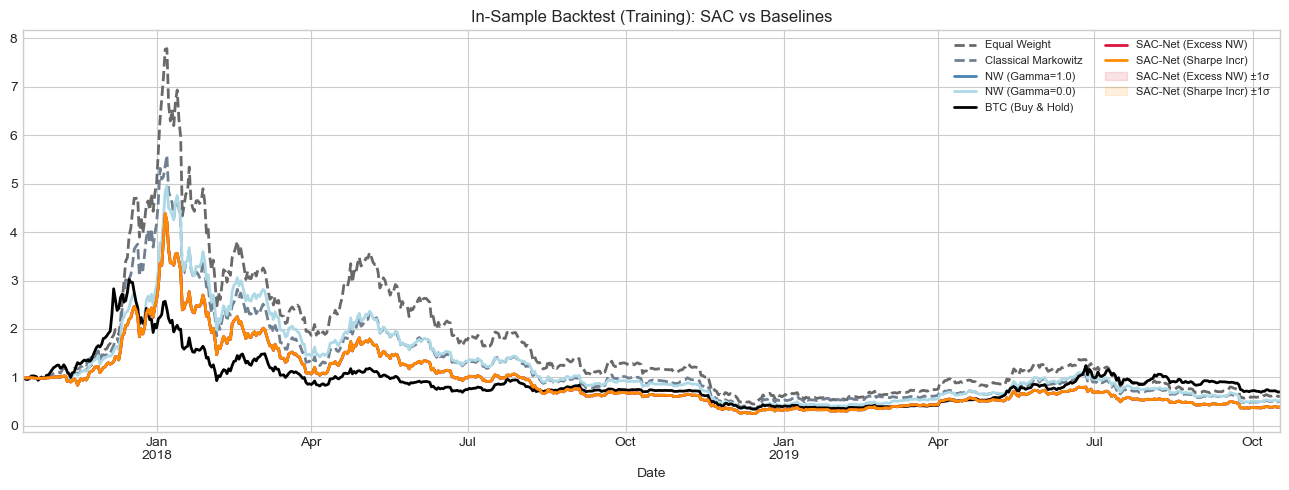

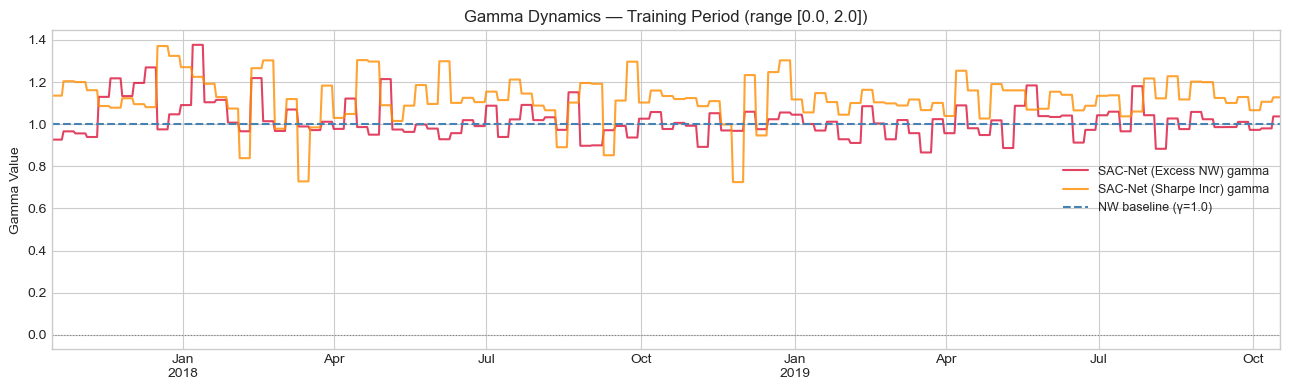

In [12]:
# ── Plot 1: Cumulative Returns (Training) ────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
for name, r in results_train.items():
    (1 + r).cumprod().plot(
        ax=ax, label=name,
        color=COLORS.get(name, 'purple'),
        linewidth=2.0,
        linestyle='--' if name in ['Equal Weight', 'Classical Markowitz'] else '-'
    )
# Tambah confidence band untuk SAC
for mode, label in reward_modes.items():
    sr   = sac_seed_results_train[(mode, label)]
    mean_r, std_r = aggregate_seed_results(sr)
    cum_mean = (1 + mean_r).cumprod()
    cum_std  = std_r * np.sqrt(np.arange(1, len(std_r)+1))  # approx
    ax.fill_between(
        cum_mean.index,
        (cum_mean - cum_std).clip(lower=0),
        cum_mean + cum_std,
        alpha=0.12, color=COLORS.get(label, 'purple'), label=f'{label} ±1σ'
    )
ax.set_title('In-Sample Backtest (Training): SAC vs Baselines')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

# ── Plot 2: Gamma Dynamics (Training) ────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
for label, g in sac_gamma_train.items():
    g.plot(ax=ax, label=f'{label} gamma', color=COLORS.get(label, 'purple'), alpha=0.8)
ax.axhline(1.0, color='steelblue', linestyle='--', label='NW baseline (γ=1.0)')
ax.axhline(0.0, color='gray',      linestyle=':', linewidth=0.8)
ax.set_title(f'Gamma Dynamics — Training Period (range [{GAMMA_CENTER-GAMMA_RANGE}, {GAMMA_CENTER+GAMMA_RANGE}])')
ax.set_ylabel('Gamma Value')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [13]:
# ── Performance Metrics Table (Training) ─────────────────────────────────
stats_train = pd.DataFrame(
    {name: calculate_metrics(r) for name, r in results_train.items()}
).T
stats_train.index.name = 'Strategy'

# Tambah kolom std Sharpe dari multi-seed
sharpe_std_train = {}
for mode, label in reward_modes.items():
    sr = sac_seed_results_train[(mode, label)]
    sharpe_per_seed = [calculate_metrics(r)['Sharpe Ratio'] for r, _ in sr.values()]
    sharpe_std_train[label] = np.std(sharpe_per_seed)

stats_train['Sharpe Std (seeds)'] = pd.Series(sharpe_std_train)

# Simpan CSV
csv_dir = 'backtest_results'
os.makedirs(csv_dir, exist_ok=True)
stats_train.to_csv(os.path.join(csv_dir, 'sac_training_metrics.csv'))
pd.DataFrame({n: (1+r).cumprod() for n, r in results_train.items()}).to_csv(
    os.path.join(csv_dir, 'sac_training_cumret.csv')
)

print('=== In-Sample Performance Metrics (Training) ===')
print(stats_train.round(4).to_string())
print(f'\nCSV saved to: {csv_dir}/')

=== In-Sample Performance Metrics (Training) ===
                       Total Return  Ann. Return  Ann. Volatility  Sharpe Ratio  Calmar Ratio  Max Drawdown  Sharpe Std (seeds)
Strategy                                                                                                                       
Equal Weight                -0.3808      -0.1519           0.8058       -0.1886       -0.1613       -0.9421                 NaN
Classical Markowitz         -0.4880      -0.2056           0.7687       -0.2674       -0.2195       -0.9367                 NaN
NW (Gamma=1.0)              -0.6087      -0.2757           0.7492       -0.3680       -0.2927       -0.9419                 NaN
NW (Gamma=0.0)              -0.4762      -0.1994           0.7308       -0.2728       -0.2141       -0.9310                 NaN
BTC (Buy & Hold)            -0.2984      -0.1147           0.6842       -0.1676       -0.1295       -0.8855                 NaN
SAC-Net (Excess NW)         -0.6086      -0.2756       

## Phase 7: Weight Concentration Diagnostic (Training Data)

Processing NW (Gamma=1.0) (Freq: 7 days)...
=== Rata-rata Bobot NW (Gamma=1.0) — Training ===
BTC    0.2398
BNB    0.1887
XRP    0.1365
XLM    0.0956
LTC    0.0931
ETH    0.0907
TRX    0.0646
BCH    0.0463
EOS    0.0446


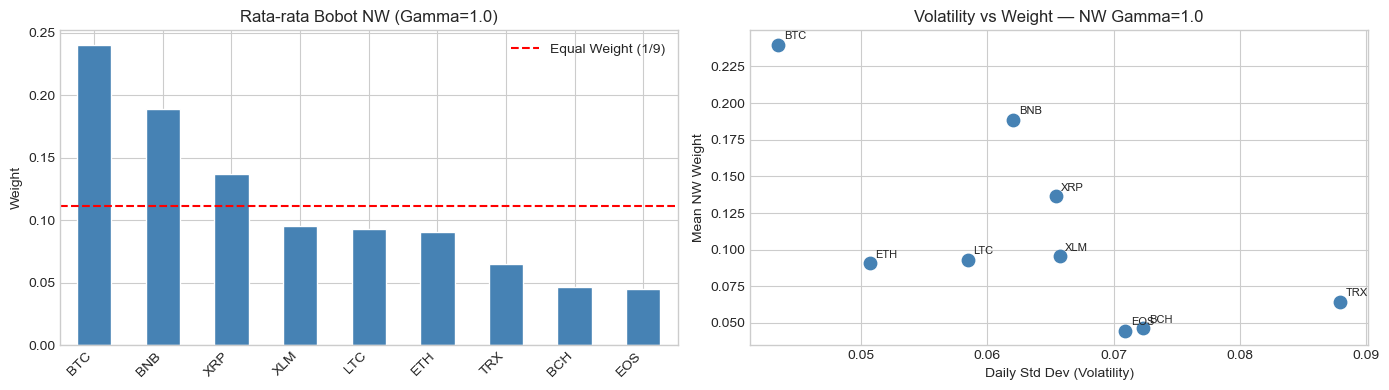


=== Days with Weight > 30% ===
BTC    313
BNB    140
XRP     63
ETH     56
BCH     35
LTC     28
XLM     21
EOS      7
TRX      7

=== Asset Stats vs Weight ===
     Mean Daily Return  Std (Volatility)  Mean Weight
BTC           0.001236          0.043442     0.239818
ETH          -0.000772          0.050690     0.090707
LTC           0.000364          0.058470     0.093139
BNB           0.002927          0.062061     0.188655
XRP           0.000432          0.065416     0.136544
XLM           0.000629          0.065719     0.095576
EOS           0.001207          0.070927     0.044605
BCH          -0.001420          0.072359     0.046324
TRX           0.002471          0.087912     0.064632


In [14]:
nw_strat = NetworkMarkowitz('NW (Gamma=1.0)', gamma=1.0)
_, nw_wts_train, _ = run_backtest_with_frequency(
    nw_strat, ret_old, window=SET_WINDOW, rebalance_freq=SET_REBALANCE
)

mean_wts = nw_wts_train.mean().sort_values(ascending=False)
print('=== Rata-rata Bobot NW (Gamma=1.0) — Training ===')
print(mean_wts.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart bobot
mean_wts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axhline(1/len(assets), color='red', linestyle='--', label=f'Equal Weight (1/{len(assets)})')
axes[0].set_title('Rata-rata Bobot NW (Gamma=1.0)')
axes[0].set_ylabel('Weight')
axes[0].legend()
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')

# Scatter volatilitas vs bobot
asset_stats = pd.DataFrame({
    'Mean Daily Return': ret_old.mean(),
    'Std (Volatility)' : ret_old.std(),
    'Mean Weight'      : mean_wts,
}).sort_values('Std (Volatility)')
axes[1].scatter(asset_stats['Std (Volatility)'], asset_stats['Mean Weight'],
                s=80, color='steelblue')
for idx, row in asset_stats.iterrows():
    axes[1].annotate(idx, (row['Std (Volatility)'], row['Mean Weight']),
                     textcoords='offset points', xytext=(4, 4), fontsize=8)
axes[1].set_xlabel('Daily Std Dev (Volatility)')
axes[1].set_ylabel('Mean NW Weight')
axes[1].set_title('Volatility vs Weight — NW Gamma=1.0')

plt.tight_layout()
plt.show()

dominant_days = (nw_wts_train > 0.30).sum()
print('\n=== Days with Weight > 30% ===')
print(dominant_days[dominant_days > 0].sort_values(ascending=False).to_string())
print('\n=== Asset Stats vs Weight ===')
print(asset_stats.round(6).to_string())

## Phase 8: Out-of-Sample Backtest (2024 Data)

Evaluasi generalisasi model SAC pada data 2024 yang **tidak pernah dilihat saat training**.

In [15]:
# ── Baseline OOS ─────────────────────────────────────────────────────────
results_2024 = {}
for s in baseline_strategies:
    s2 = s.__class__(s.name, **({'gamma': s.gamma} if isinstance(s, NetworkMarkowitz) else {}))
    ret, _, _ = run_backtest_with_frequency(
        s2, ret_2024, window=SET_WINDOW, rebalance_freq=SET_REBALANCE
    )
    results_2024[s.name] = ret

if 'BTC' in ret_2024.columns:
    results_2024['BTC (Buy & Hold)'] = ret_2024['BTC'].iloc[SET_WINDOW:]

# ── SAC OOS (multi-seed) ──────────────────────────────────────────────────
sac_seed_results_2024 = {}
sac_gamma_2024        = {}

for mode, label in reward_modes.items():
    sr = run_multiseed_backtest(mode, label, ret_2024)
    sac_seed_results_2024[(mode, label)] = sr
    mean_ret, _ = aggregate_seed_results(sr)
    mean_ret.name = label
    results_2024[label] = mean_ret
    sac_gamma_2024[label] = sr[SEEDS[0]][1]

print('Out-of-sample backtest complete.')

Processing Equal Weight (Freq: 7 days)...
Processing Classical Markowitz (Freq: 7 days)...
Processing NW (Gamma=1.0) (Freq: 7 days)...
Processing NW (Gamma=0.0) (Freq: 7 days)...
Processing SAC-Net (Excess NW) [s42] (Freq: 7 days)...
Processing SAC-Net (Sharpe Incr) [s42] (Freq: 7 days)...
Out-of-sample backtest complete.


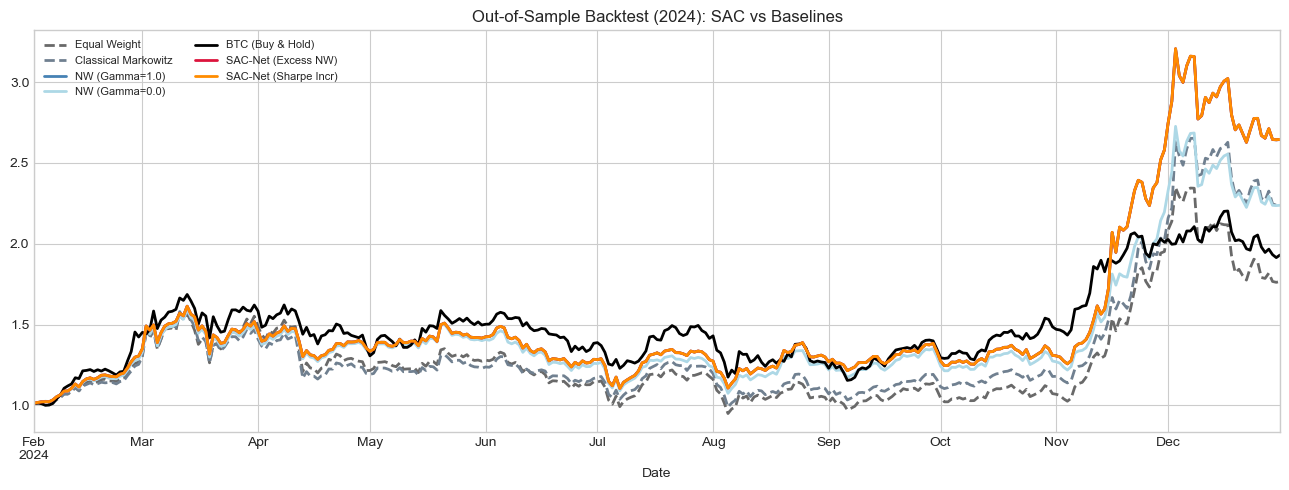

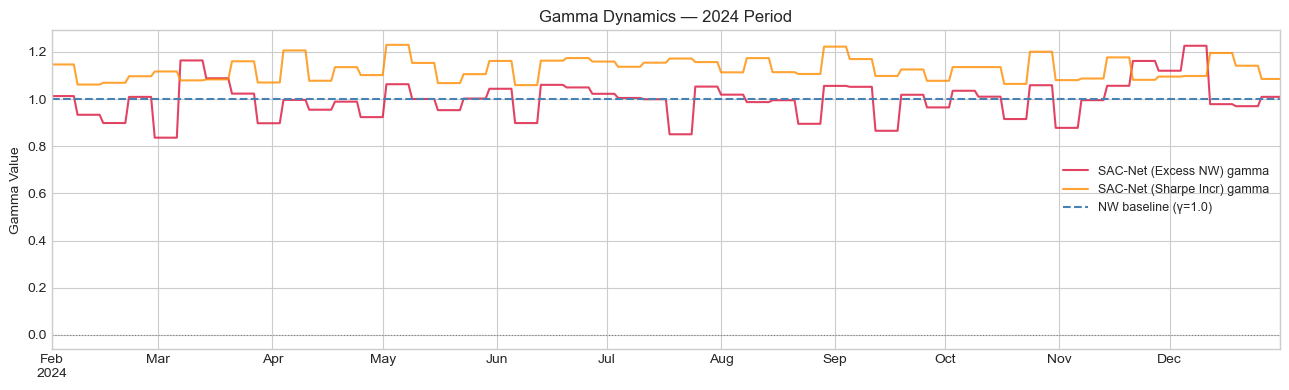

In [16]:
# ── Plot 1: Cumulative Returns (2024) ────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
for name, r in results_2024.items():
    (1 + r).cumprod().plot(
        ax=ax, label=name,
        color=COLORS.get(name, 'purple'),
        linewidth=2.0,
        linestyle='--' if name in ['Equal Weight', 'Classical Markowitz'] else '-'
    )
# Confidence band
for mode, label in reward_modes.items():
    sr = sac_seed_results_2024[(mode, label)]
    mean_r, std_r = aggregate_seed_results(sr)
    cum_mean = (1 + mean_r).cumprod()
    cum_std  = std_r * np.sqrt(np.arange(1, len(std_r)+1))
    ax.fill_between(
        cum_mean.index,
        (cum_mean - cum_std).clip(lower=0),
        cum_mean + cum_std,
        alpha=0.12, color=COLORS.get(label, 'purple')
    )
ax.set_title('Out-of-Sample Backtest (2024): SAC vs Baselines')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

# ── Plot 2: Gamma Dynamics (2024) ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
for label, g in sac_gamma_2024.items():
    g.plot(ax=ax, label=f'{label} gamma', color=COLORS.get(label, 'purple'), alpha=0.8)
ax.axhline(1.0, color='steelblue', linestyle='--', label='NW baseline (γ=1.0)')
ax.axhline(0.0, color='gray',      linestyle=':', linewidth=0.8)
ax.set_title(f'Gamma Dynamics — 2024 Period')
ax.set_ylabel('Gamma Value')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [17]:
# ── Performance Metrics Table (2024) ─────────────────────────────────────
stats_2024 = pd.DataFrame(
    {name: calculate_metrics(r) for name, r in results_2024.items()}
).T
stats_2024.index.name = 'Strategy'

sharpe_std_2024 = {}
for mode, label in reward_modes.items():
    sr = sac_seed_results_2024[(mode, label)]
    sharpe_per_seed = [calculate_metrics(r)['Sharpe Ratio'] for r, _ in sr.values()]
    sharpe_std_2024[label] = np.std(sharpe_per_seed)

stats_2024['Sharpe Std (seeds)'] = pd.Series(sharpe_std_2024)

# Simpan CSV
stats_2024.to_csv(os.path.join(csv_dir, 'sac_2024_metrics.csv'))
pd.DataFrame({n: (1+r).cumprod() for n, r in results_2024.items()}).to_csv(
    os.path.join(csv_dir, 'sac_2024_cumret.csv')
)

print('=== Out-of-Sample Performance Metrics (2024) ===')
print(stats_2024.round(4).to_string())
print(f'\nCSV saved to: {csv_dir}/')

=== Out-of-Sample Performance Metrics (2024) ===
                       Total Return  Ann. Return  Ann. Volatility  Sharpe Ratio  Calmar Ratio  Max Drawdown  Sharpe Std (seeds)
Strategy                                                                                                                       
Equal Weight                 0.7665       0.5342           0.4820        1.1083        1.3486       -0.3961                 NaN
Classical Markowitz          1.2467       0.8384           0.4745        1.7670        2.2348       -0.3752                 NaN
NW (Gamma=1.0)               1.6446       1.0783           0.4668        2.3101        3.4209       -0.3152                 NaN
NW (Gamma=0.0)               1.2376       0.8328           0.4363        1.9087        2.5586       -0.3255                 NaN
BTC (Buy & Hold)             0.9301       0.6399           0.4405        1.4527        2.0299       -0.3153                 NaN
SAC-Net (Excess NW)          1.6449       1.0785       

## Phase 9: SAC vs PPO Comparison (Opsional)

Jika ingin membandingkan SAC dengan PPO versi sebelumnya secara langsung di tesis. 
Jalankan cell ini **setelah** memastikan model PPO (`ppo_nw_excess_v2.zip`) tersedia.

In [18]:
import os

ppo_models_exist = (
    os.path.exists('ppo_nw_excess_v2.zip') and
    os.path.exists('ppo_nw_riskadj_v2.zip')
)

if ppo_models_exist:
    print('PPO models found — running comparison...')
    ppo_strats = [
        RLNetworkMarkowitz('PPO-Net (Excess NW)',  'ppo_nw_excess_v2',  algo='ppo',
                           gamma_center=GAMMA_CENTER, gamma_range=GAMMA_RANGE),
        RLNetworkMarkowitz('PPO-Net (Risk-Adj)',   'ppo_nw_riskadj_v2', algo='ppo',
                           gamma_center=GAMMA_CENTER, gamma_range=GAMMA_RANGE),
    ]
    results_cmp = dict(results_2024)  # copy hasil SAC
    for s in ppo_strats:
        ret, _, _ = run_backtest_with_frequency(
            s, ret_2024, window=SET_WINDOW, rebalance_freq=SET_REBALANCE
        )
        results_cmp[s.name] = ret

    stats_cmp = pd.DataFrame(
        {n: calculate_metrics(r) for n, r in results_cmp.items()}
    ).T
    print('\n=== SAC vs PPO — OOS 2024 ===')
    # Tampilkan hanya baris relevan
    highlight = [c for c in stats_cmp.index if 'SAC' in c or 'PPO' in c or 'NW' in c]
    print(stats_cmp.loc[highlight].round(4).to_string())
    stats_cmp.to_csv(os.path.join(csv_dir, 'sac_vs_ppo_comparison.csv'))
else:
    print('PPO model files tidak ditemukan.')
    print('Jalankan versi PPO terlebih dahulu, atau skip cell ini.')

PPO models found — running comparison...
Processing PPO-Net (Excess NW) (Freq: 7 days)...
Processing PPO-Net (Risk-Adj) (Freq: 7 days)...

=== SAC vs PPO — OOS 2024 ===
                       Total Return  Ann. Return  Ann. Volatility  Sharpe Ratio  Calmar Ratio  Max Drawdown
NW (Gamma=1.0)               1.6446       1.0783           0.4668        2.3101        3.4209       -0.3152
NW (Gamma=0.0)               1.2376       0.8328           0.4363        1.9087        2.5586       -0.3255
SAC-Net (Excess NW)          1.6449       1.0785           0.4668        2.3104        3.4215       -0.3152
SAC-Net (Sharpe Incr)        1.6454       1.0788           0.4669        2.3108        3.4225       -0.3152
PPO-Net (Excess NW)          1.3411       0.8962           0.4360        2.0557        2.8486       -0.3146
PPO-Net (Risk-Adj)           1.6384       1.0747           0.4659        2.3068        3.4369       -0.3127
